# Exploration approfondie de la base d'apprentissage

In [1]:
import pandas as pd
import sys
import os
import warnings
import pingouin as pg

warnings.filterwarnings("ignore")

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

from eda import *

In [2]:
# Configuration
FILE_PATH = "../data_finale/test.csv"
TARGET    = "market_value_in_eur"
dossier_sauvegarde = "../outputs/eda"

In [3]:
# Chargement de la base de données

df_base = pd.read_csv(FILE_PATH)

In [4]:
print("Types des variables")

analyser_types(df_base)

Types des variables
Analyse des types de variables
Variables numériques   : 150
Variables catégorielles: 4


Analyse des valeurs manquantes
                         nb_missing    pct
xg                              999  37.14
xg_buildup                      999  37.14
xa_nor                          999  37.14
xa                              999  37.14
xg_nor                          999  37.14
xg_buildup_nor                  999  37.14
Subs_Mn/Sub                     374  13.90
Subs_Mn/Sub_nor                 374  13.90
contrat_jours_restants          333  12.38
height_in_cm                    225   8.36
market_value_in_eur             224   8.33
market_value_in_eur_nor         224   8.33
Team Success_On-Off              22   0.82
nation                            2   0.07

Graphique sauvegardé sous : ..\outputs\eda\valeurs_manquantes.png


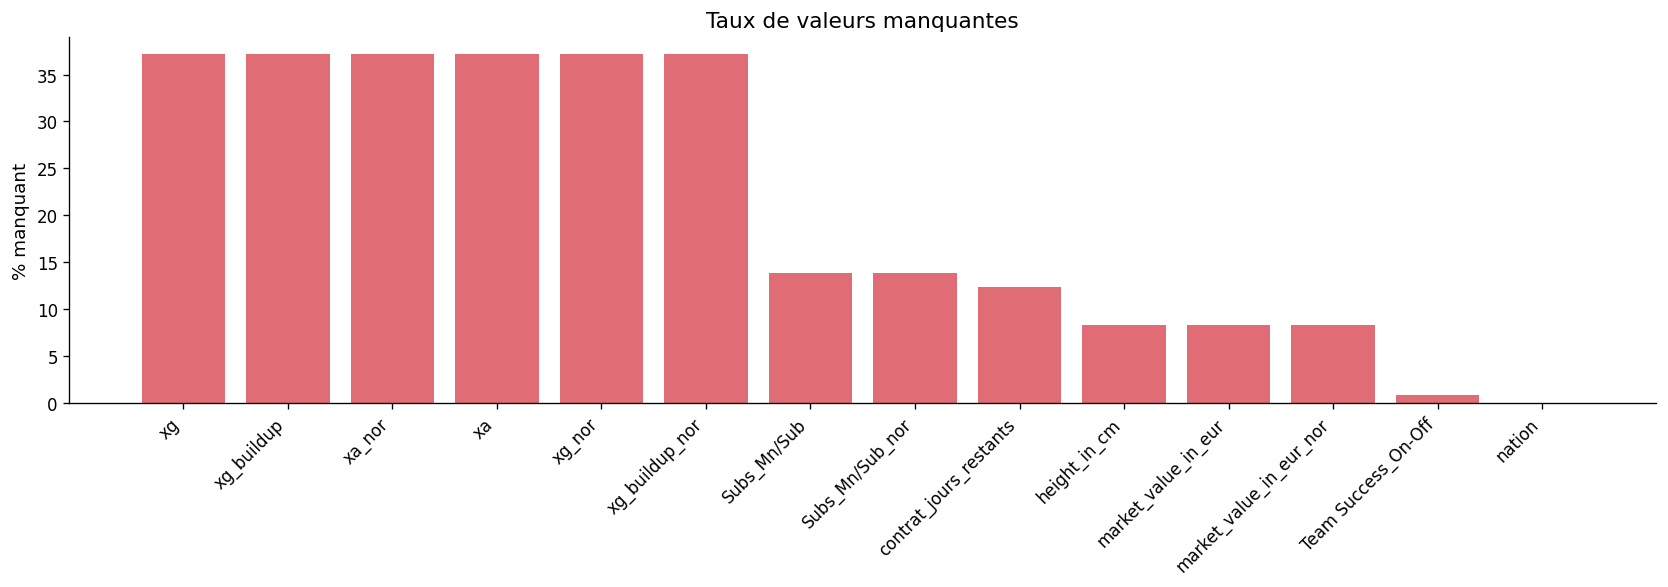

In [5]:
analyser_valeurs_manquantes(df_base, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la variable cible : market_value_in_eur
count          2,466
mean      10,963,382
std       14,958,656
min           50,000
25%        2,000,000
50%        5,500,000
75%       15,000,000
max      180,000,000
Name: market_value_in_eur, dtype: str

Skewness : 3.26
Kurtosis : 17.05

Graphique sauvegardé sous : ..\outputs\eda\distribution_market_value_in_eur.png


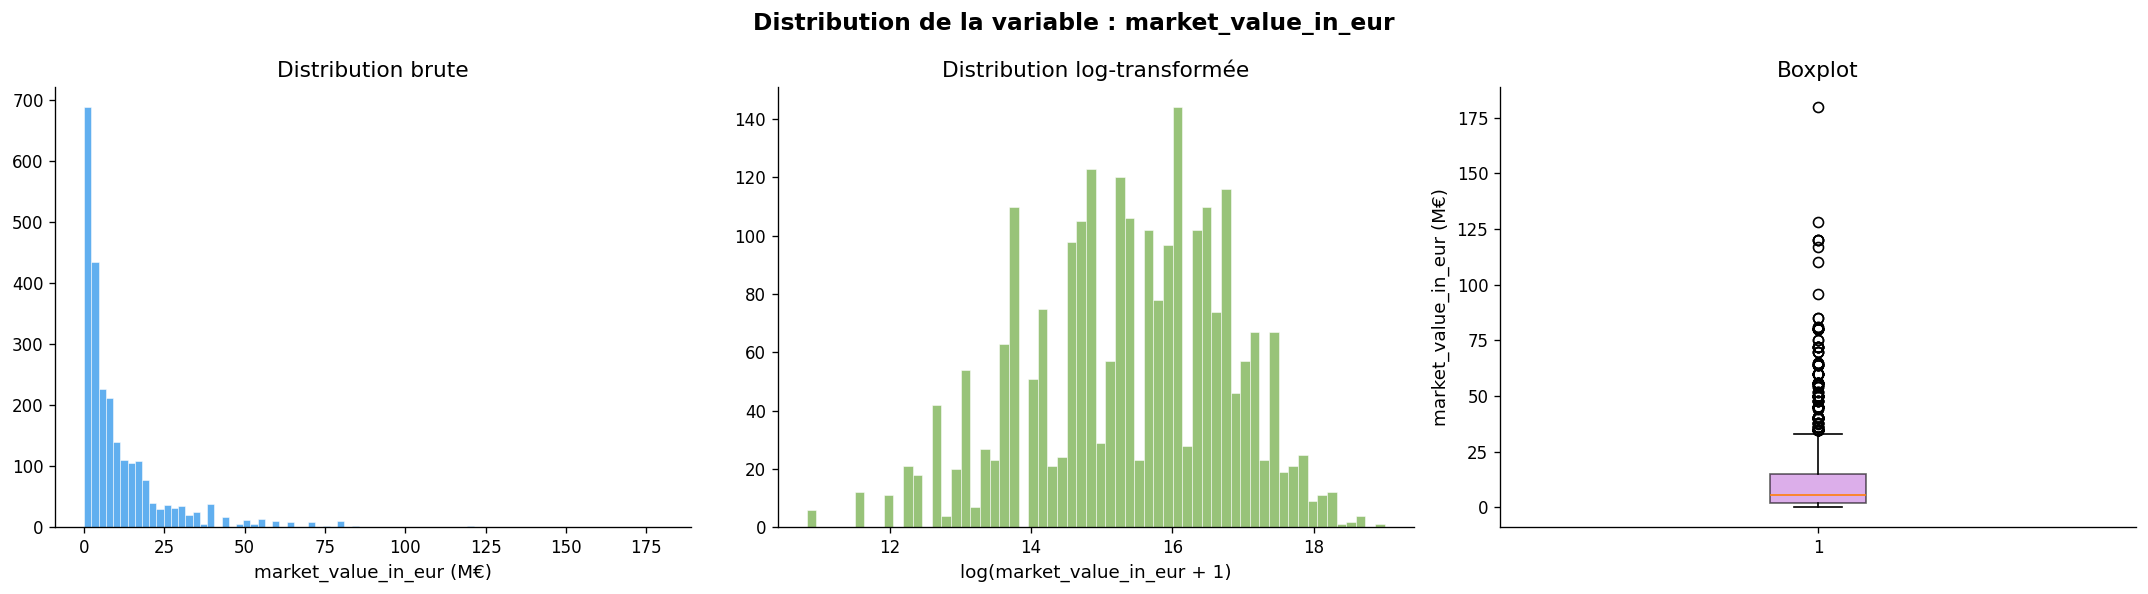

In [6]:
analyser_variable_cible(df_base, target_col=TARGET, dossier_sauvegarde=dossier_sauvegarde)

Distributions des variables numériques clés

Graphique sauvegardé sous : ..\outputs\eda\distributions_variables_numeriques_cles.png


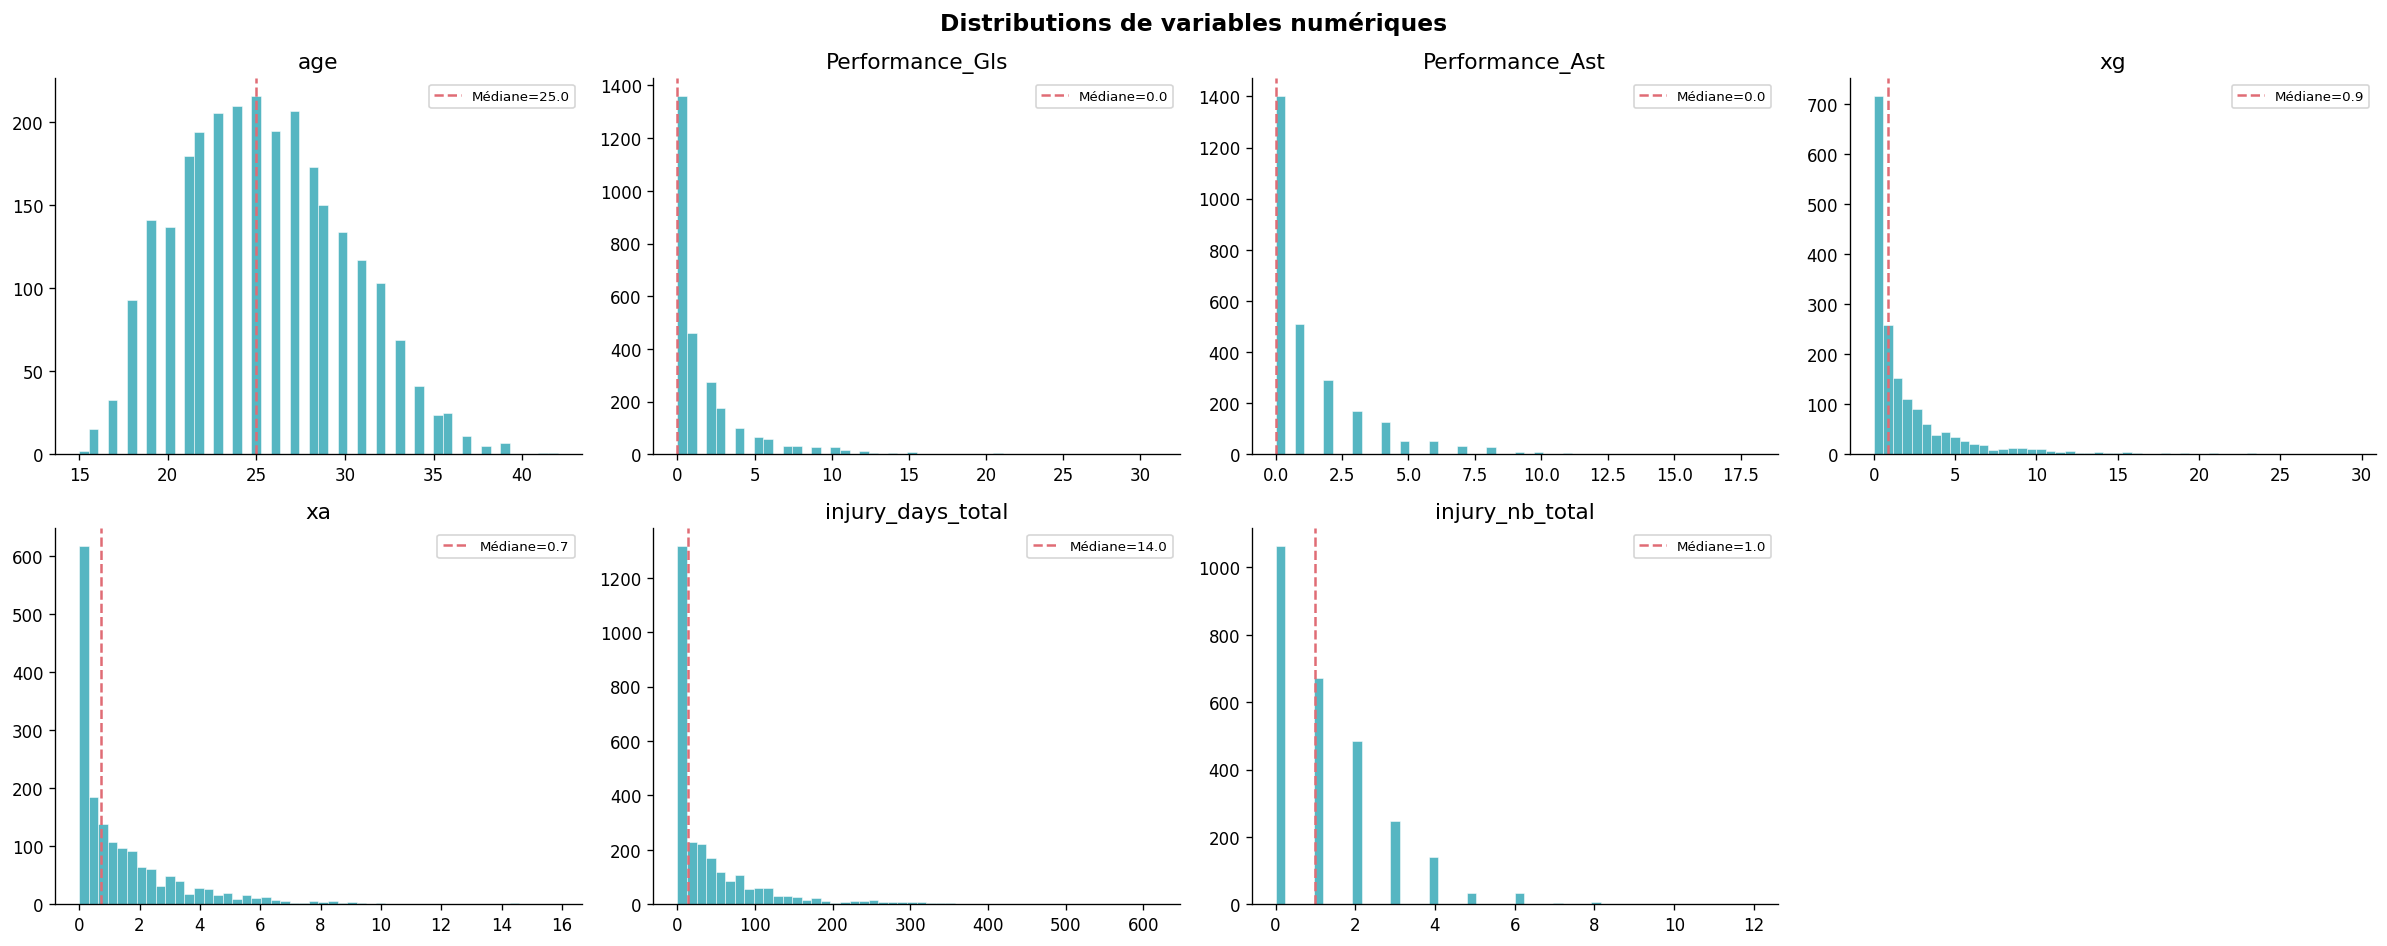

In [7]:
analyser_distributions_numeriques(df_base, cols_a_analyser=None, dossier_sauvegarde=dossier_sauvegarde)

Analyse des variables catégorielles

league (5 modalités encodées) :
ITA-Serie A           583
ESP-La Liga           574
ENG-Premier League    542
FRA-Ligue 1           529
GER-Bundesliga        462

players_top_nations.png sauvegardé


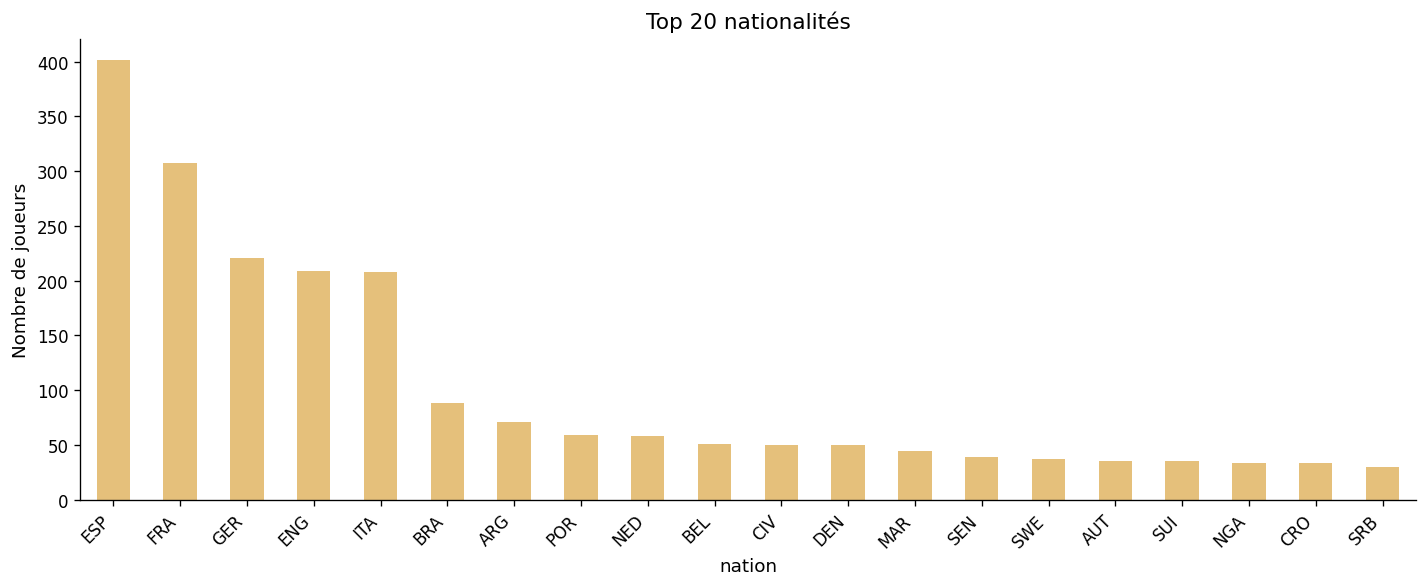

league.png sauvegardé


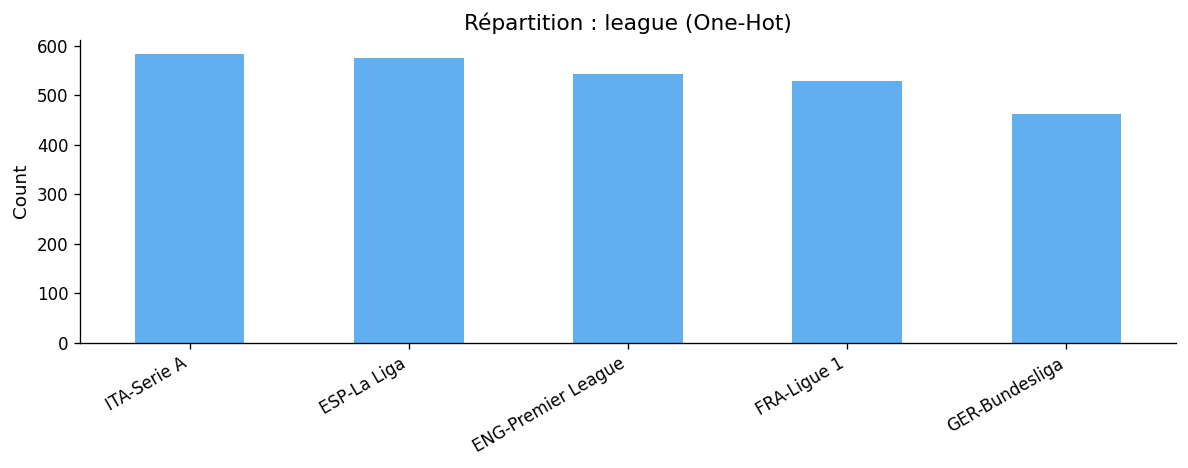

vm_par_league.png sauvegardé


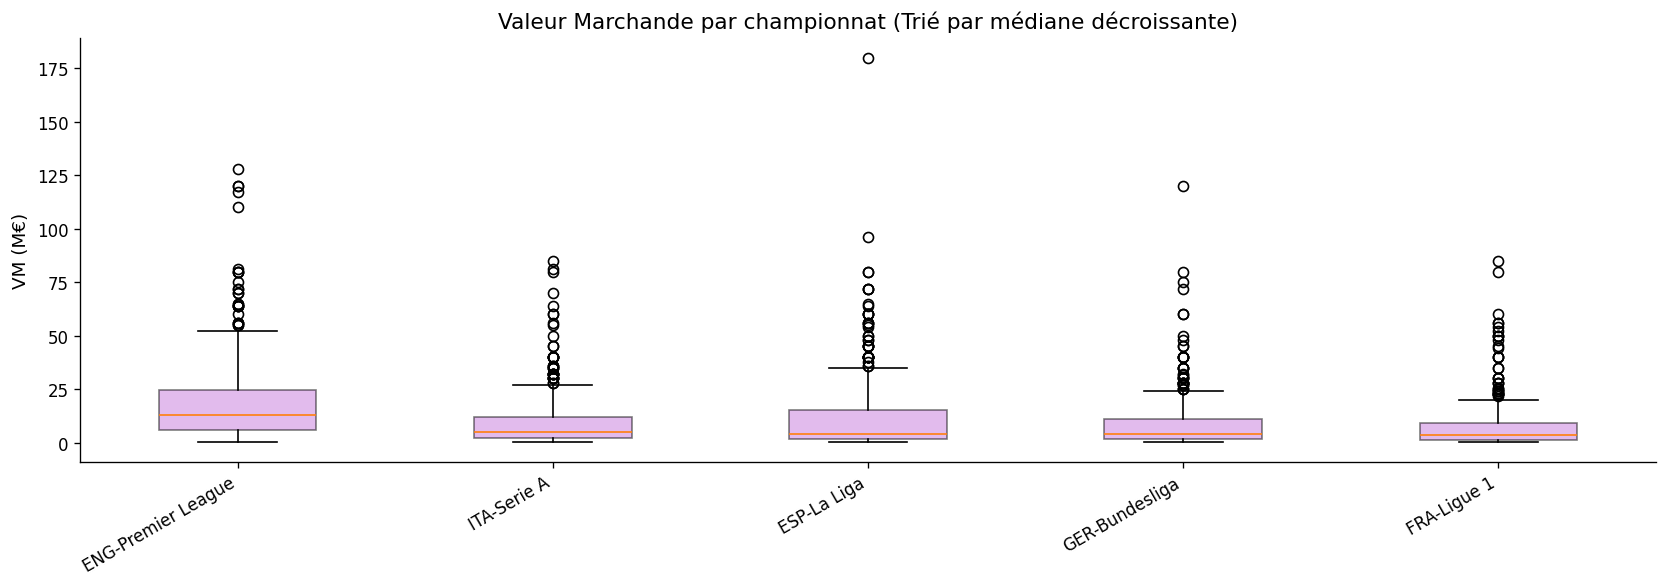

In [8]:
analyser_variables_categorielles(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

In [9]:
analyser_outliers(df_base)

Détection des outliers
         variable  outliers_IQR  pct_IQR  outliers_Zscore  total
              age             2      0.1                2   2690
  Performance_Gls           253      9.4               59   2690
  Performance_Ast           140      5.2               56   2690
               xg           144      8.5               39   1691
               xa           109      6.4               35   1691
injury_days_total           218      8.1               75   2690
  injury_nb_total            46      1.7               46   2690


Analyse des corrélations (cible : market_value_in_eur)

Corrélation linéaire avec la cible (variables clés)
                     market_value_in_eur
market_value_in_eur             1.000000
Performance_Gls                 0.306165
xa                              0.300625
xg                              0.299203
Performance_Ast                 0.278325
injury_nb_total                 0.160570
age                             0.158159
injury_days_total               0.060287

matrice_correlation.png sauvegardé sous : ..\outputs\eda\matrice_correlation.png


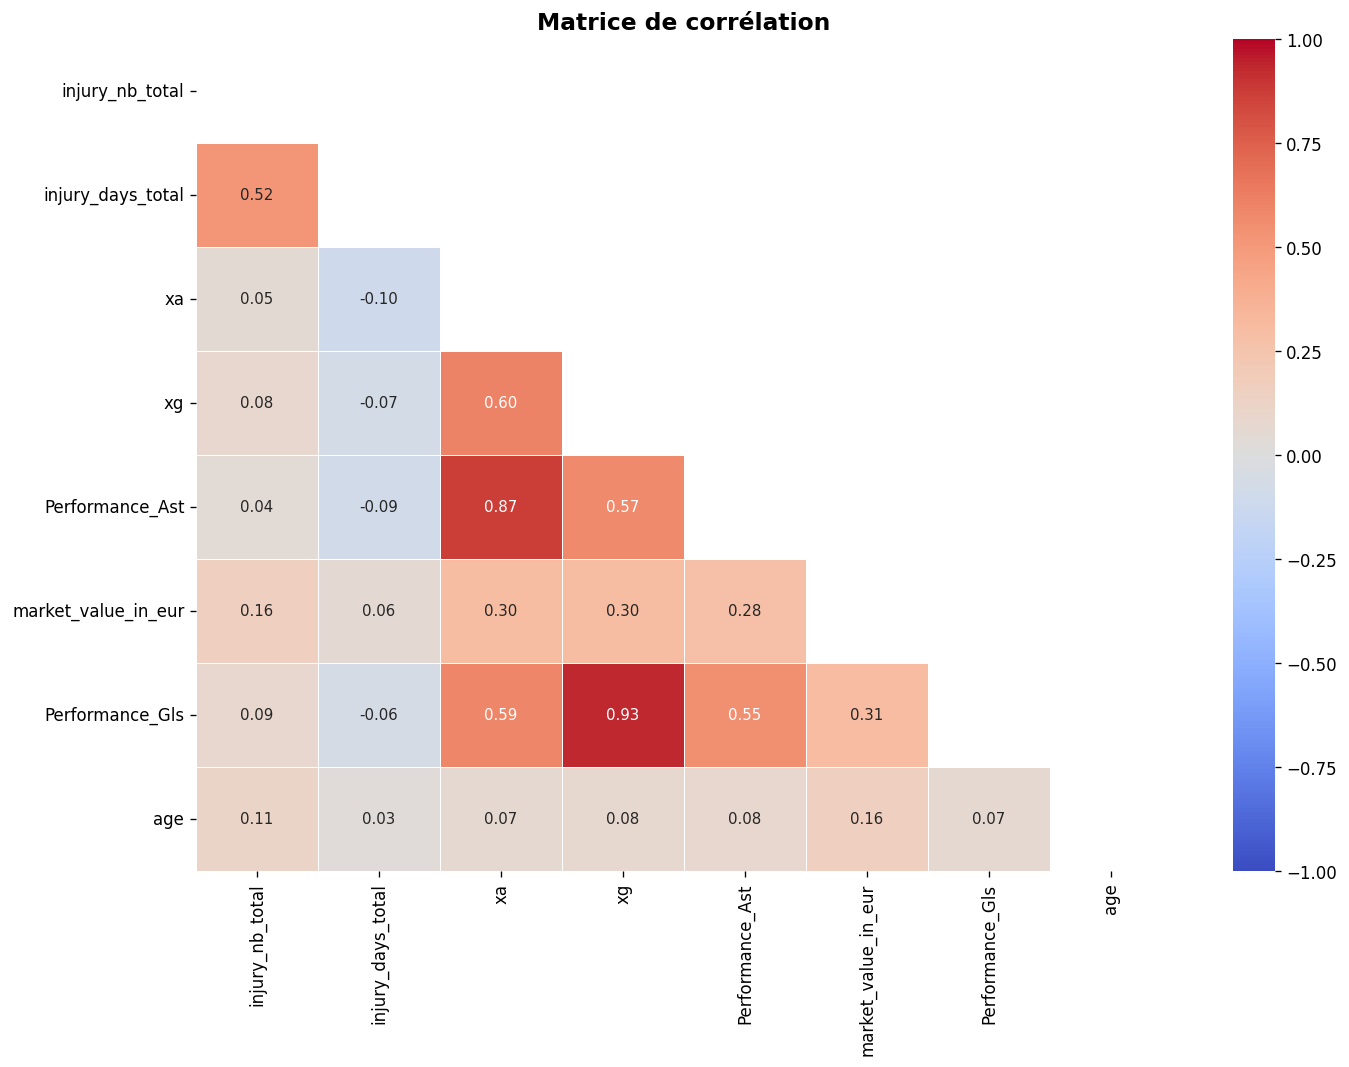


Top 20 des corrélations absolues avec market_value_in_eur (Toutes variables numériques)
market_value_in_eur_nor      1.000000
Team Success_onG             0.366025
xg_buildup                   0.356308
xg_buildup_nor               0.356308
Standard_SoT                 0.314871
Standard_SoT_nor             0.314871
Standard_Sh_nor              0.306273
Standard_Sh                  0.306273
Performance_Gls              0.306165
Performance_Gls_nor          0.306165
xa                           0.300625
xa_nor                       0.300625
xg                           0.299203
xg_nor                       0.299203
Performance_G-PK             0.291837
Performance_Ast              0.278325
Performance_Ast_nor          0.278325
Team Success_PPM             0.274991
Team Success_PPM_nor         0.274991
league_ENG-Premier League    0.246965


In [10]:
analyser_correlations(df_base, TARGET, cols_cles=None, dossier_sauvegarde=dossier_sauvegarde)

## Segmentation par poste

Analyse du profil médian par poste

Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_profil_poste.png


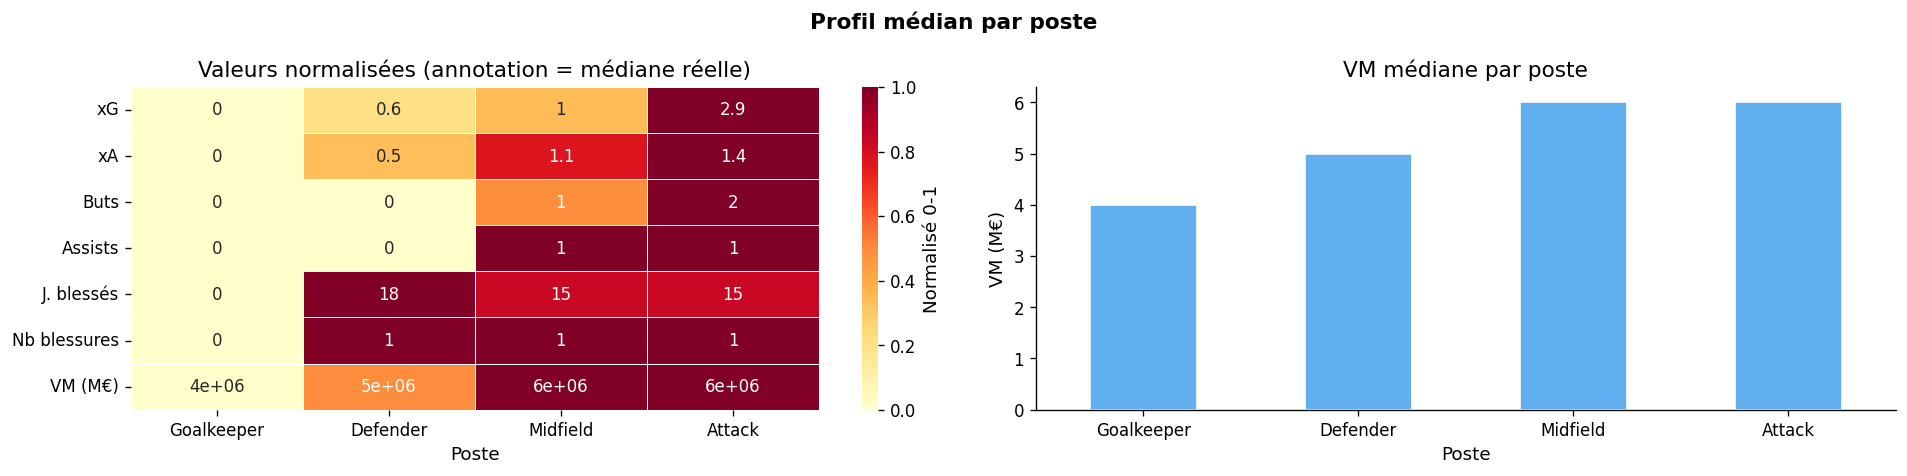

In [11]:
analyser_profil_par_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse de la distribution des âges par poste
Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_age_par_poste.png


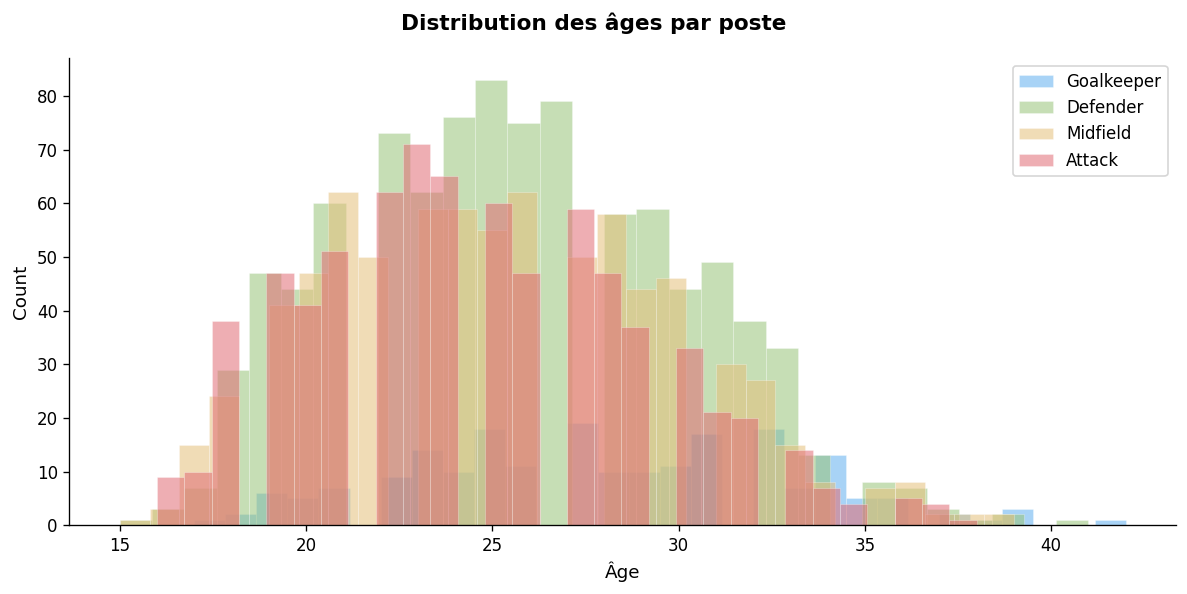


Âge médian par poste
position
Goalkeeper    28.0
Defender      25.0
Midfield      25.0
Attack        24.0


In [12]:
analyser_ages_par_poste(df_base, dossier_sauvegarde=dossier_sauvegarde, liste_couleurs=None)

Analyse croisée : VM médiane par championnat et par poste

Heatmap sauvegardée sous : ..\outputs\eda\feature_engineered_heatmap_league_pos.png


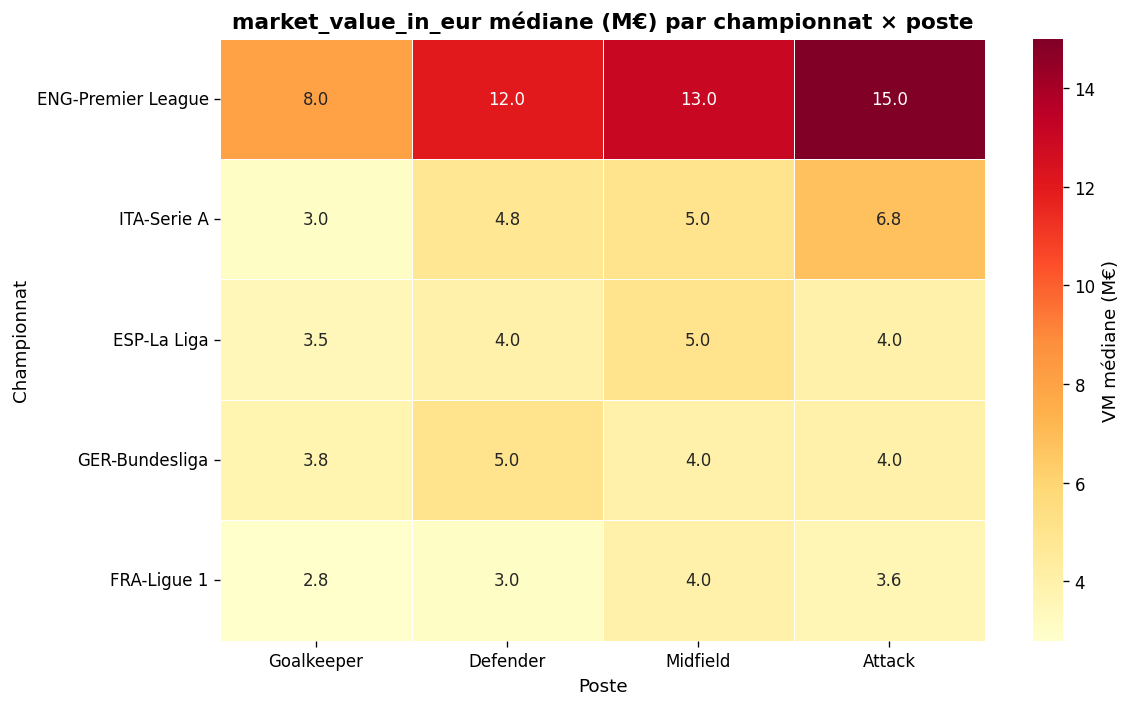

In [13]:
analyser_heatmap_league_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la distribution par championnat

Violin plot sauvegardé sous : ..\outputs\eda\feature_engineered_violin_league.png


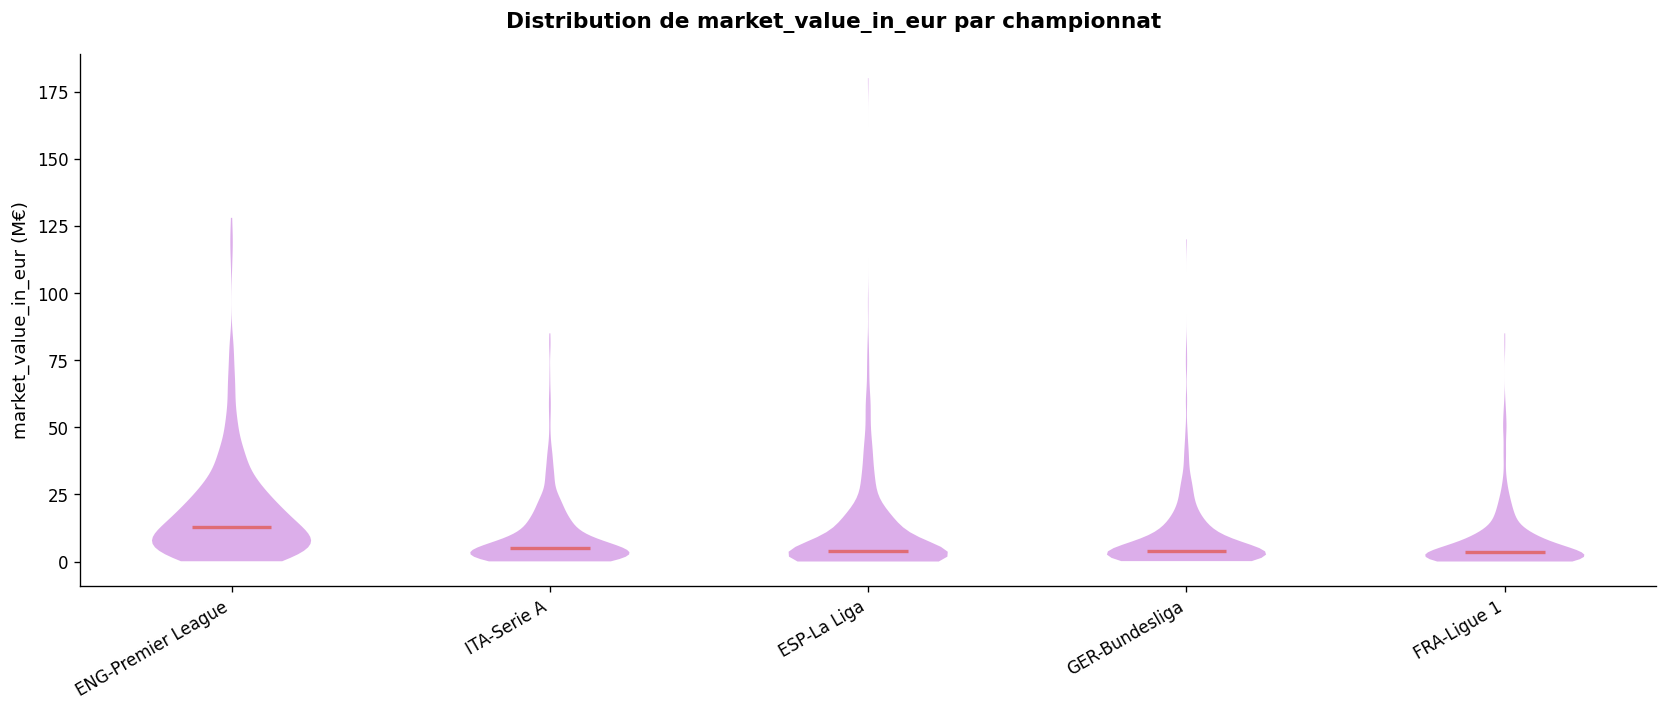

In [14]:
analyser_distribution_violin_league(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse des outliers et profils Spécifiques (cible : market_value_in_eur)

Joueurs avec market_value_in_eur ≥ 100M€ : 7 observations

Top 20 des joueurs les plus chers
                player position  age  market_value_in_eur        xg  Performance_Gls  injury_days_total
         Kylian Mbappé   Attack   26                180.0       NaN               31               25.0
       Raheem Sterling   Attack   30                128.0  0.970784                0               19.0
            Harry Kane   Attack   31                120.0 24.838503               26               15.0
         Mohamed Salah   Attack   32                120.0 27.706267               29                0.0
       Kevin De Bruyne Midfield   33                120.0  5.544451                4               44.0
          Jadon Sancho   Attack   24                117.0  2.417432                3               10.0
Trent Alexander-Arnold Defender   26                110.0  1.894136                3               64.0


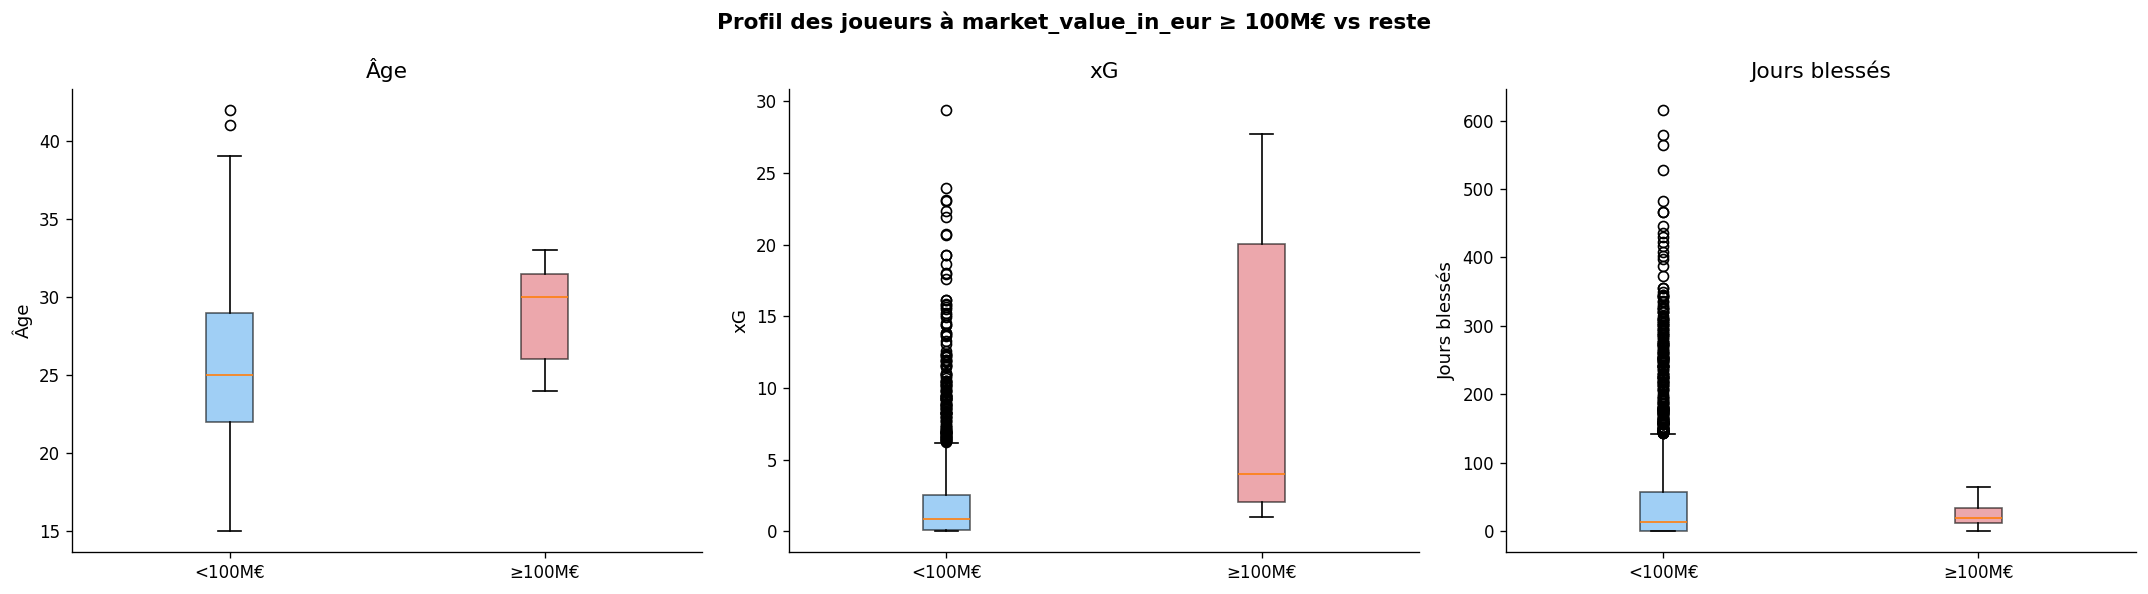

In [15]:
analyser_profil_outliers(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

In [16]:
verifier_coherence_jours_blessures(df_base)

Contrôle de cohérence : jours de blessures

Cohérence injury_days_total vs somme des composantes (2690/2690 lignes analysées) :
  Cohérents (diff = 0)           : 2,546
  Diff ≤ 1 jour                  : 2,546
  Diff > 1 jour (anomalie)       : 144
  Diff max                       : 616 jours

Des incohérences ont été détectées. Cela peut provenir de blessures
 qui se chevauchent dans le temps ou de catégories non répertoriées ici.


Analyse de l'évolution temporelle par Saison (cible : market_value_in_eur)

Évolution VM par saison :
             Médiane (M€)  Moyenne (M€)  Nb joueurs
season_year                                        
2024                  5.5     10.963382        2466

Graphique sauvegardé sous : ..\outputs\eda\evolution_temporelle.png


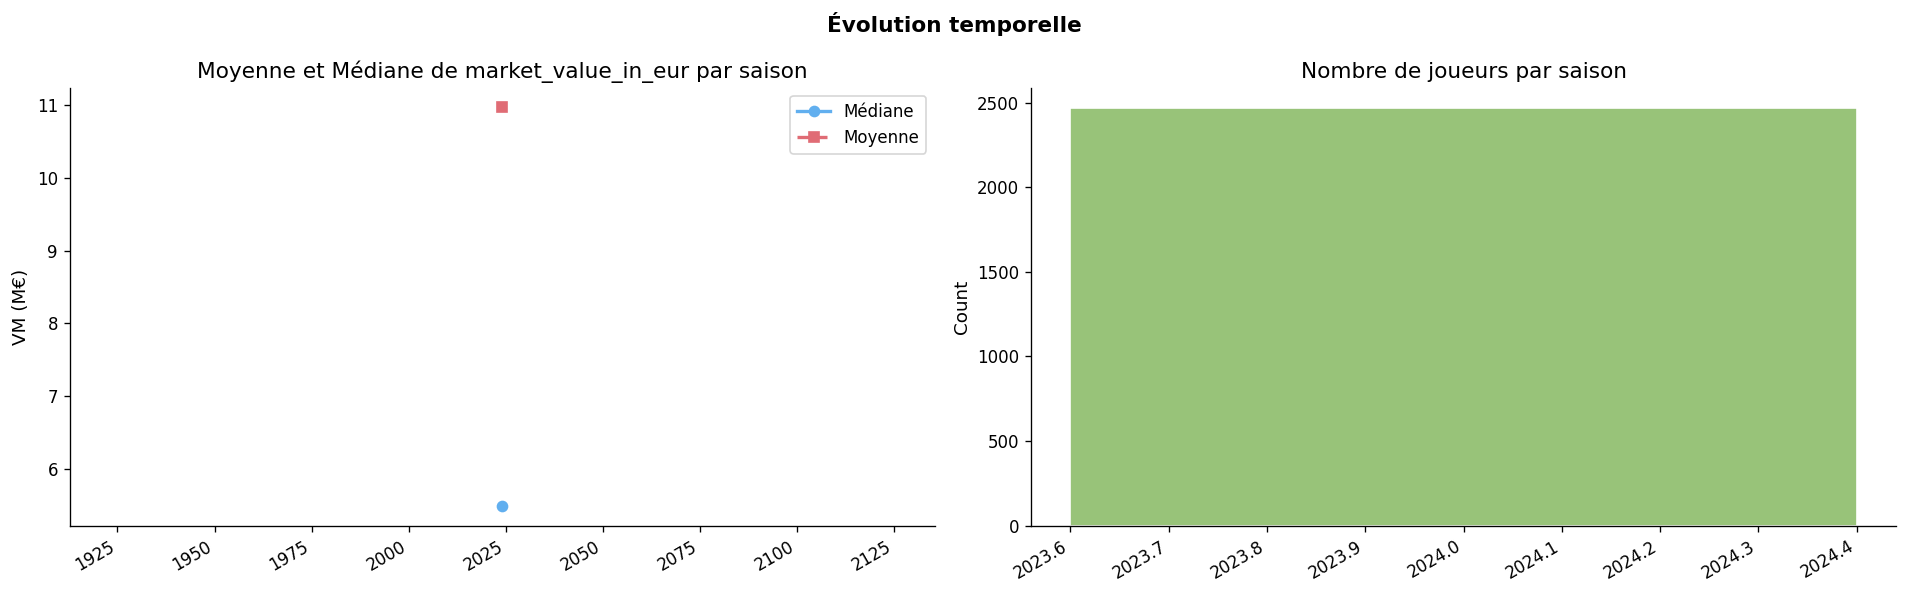

,Médiane (M€),Moyenne (M€),Nb joueurs
season_year,,,
2024,5.5,10.963382,2466


In [17]:
analyser_evolution_temporelle_saison(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Démarrage de l'analyse du cycle de vie financier...
2690 observations valides trouvées pour l'analyse graphique.


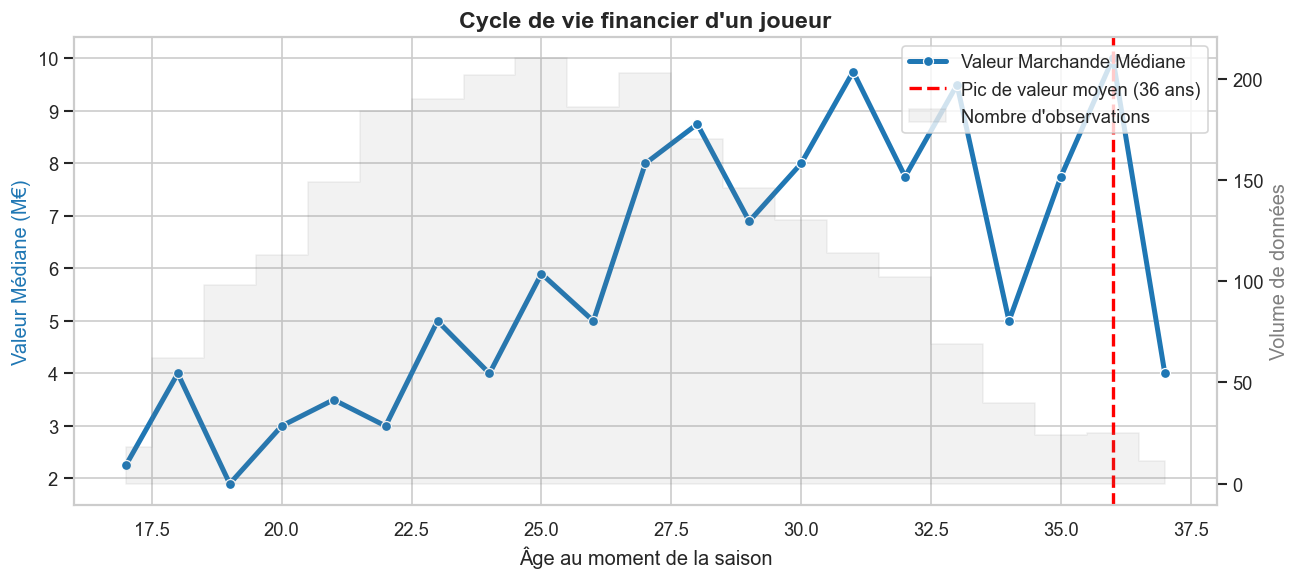


Graphique généré avec succès.


In [18]:
# Application de la fonction
df_base = analyser_cycle_vie_financier(df_base)

In [ ]:
df_base

Démarrage de l'analyse de distribution des prix...
5 championnats détectés et ordonnés pour l'affichage.


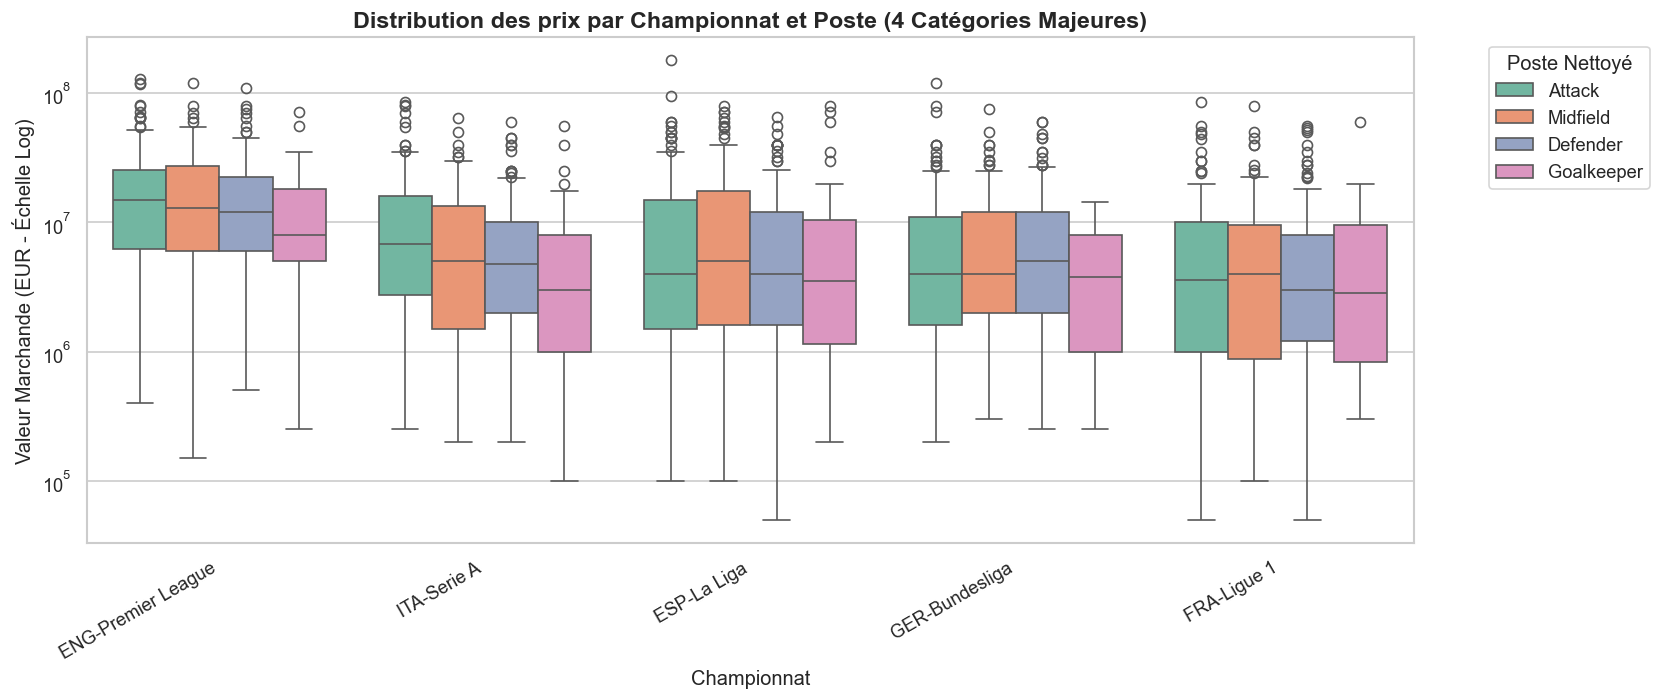


Boxplot généré avec succès.


In [19]:
analyser_distribution_prix_ligue_poste(df_base)

In [20]:
# On détecte les colinéarités
colinearites = detecter_top_colinearites(df_base, top_n=30)

# On affiche le tableau
display(colinearites)

Extraction du Top 30 des colinéarités (hors variables normalisées)...


,Variable_A,Variable_B,Correlation
0,Playing Time_90s,Playing Time_Starts,0.994
1,Performance_G-PK,Performance_Gls,0.982
2,Performance_Saves,Performance_GA,0.969
3,Performance_PKatt,Performance_PK,0.968
4,pos_GK,Performance_Save%,0.967
5,injury_dos_bassin_nb_m,injury_dos_bassin_nb_d,0.966
6,injury_mollet_tibia_nb_m,injury_mollet_tibia_nb_d,0.966
7,Standard_SoT,Standard_Sh,0.958
8,injury_genou_nb_m,injury_genou_nb_d,0.957
9,injury_cheville_pied_nb_m,injury_cheville_pied_nb_d,0.950


In [21]:
df_base

,player,team,nation,age,Playing Time_MP,Playing Time_Starts,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G-PK,...,Performance_CS%_nor,Standard_Sh_nor,Standard_SoT_nor,Standard_SoT%_nor,Standard_G/Sh_nor,Standard_G/SoT_nor,Team Success_PPM_nor,xg_nor,xa_nor,xg_buildup_nor
0,Aaron Ciammaglichella,Torino,ITA,19,1,0,0.0,0,0,0,...,0.000,0.000000,0.000000,0.0000,0.00,0.00,0.521739,0.0,0.0,0.000000
1,Aaron Cresswell,West Ham United,ENG,35,18,10,9.2,0,0,0,...,0.000,0.025641,0.000000,0.0000,0.00,0.00,0.309565,NaN,NaN,NaN
2,Aaron Malouda,Lille,FRA,19,1,0,0.0,0,0,0,...,0.000,0.000000,0.000000,0.0000,0.00,0.00,0.000000,0.0,0.0,0.000000
3,Aaron Ramsdale,Southampton,ENG,26,30,30,30.0,0,0,0,...,0.100,0.000000,0.000000,0.0000,0.00,0.00,0.064348,0.0,0.0,0.096906
4,Aaron Wan-Bissaka,West Ham United,COD,27,36,35,35.0,2,5,2,...,0.000,0.082051,0.054945,0.3125,0.12,0.20,0.203478,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2685,Þórir Jóhann Helgason,Lecce,ISL,24,21,13,12.8,0,4,0,...,0.000,0.082051,0.054945,0.3125,0.00,0.00,0.198261,NaN,NaN,NaN
2686,Đorđe Petrović,Strasbourg,SRB,25,31,31,31.0,0,0,0,...,0.323,0.000000,0.000000,0.0000,0.00,0.00,0.297391,NaN,NaN,NaN
2687,İlkay Gündoğan,Manchester City,GER,34,33,25,24.7,1,6,1,...,0.000,0.138462,0.076923,0.2593,0.04,0.07,0.337391,NaN,NaN,NaN
2688,Łukasz Fabiański,West Ham United,POL,39,14,13,12.9,0,0,0,...,0.231,0.000000,0.000000,0.0000,0.00,0.00,0.260870,NaN,NaN,NaN


Analyse des variables les plus explicatives pour : market_value_in_eur
Filtrage appliqué : Analyse exclusive des Gardiens de but.


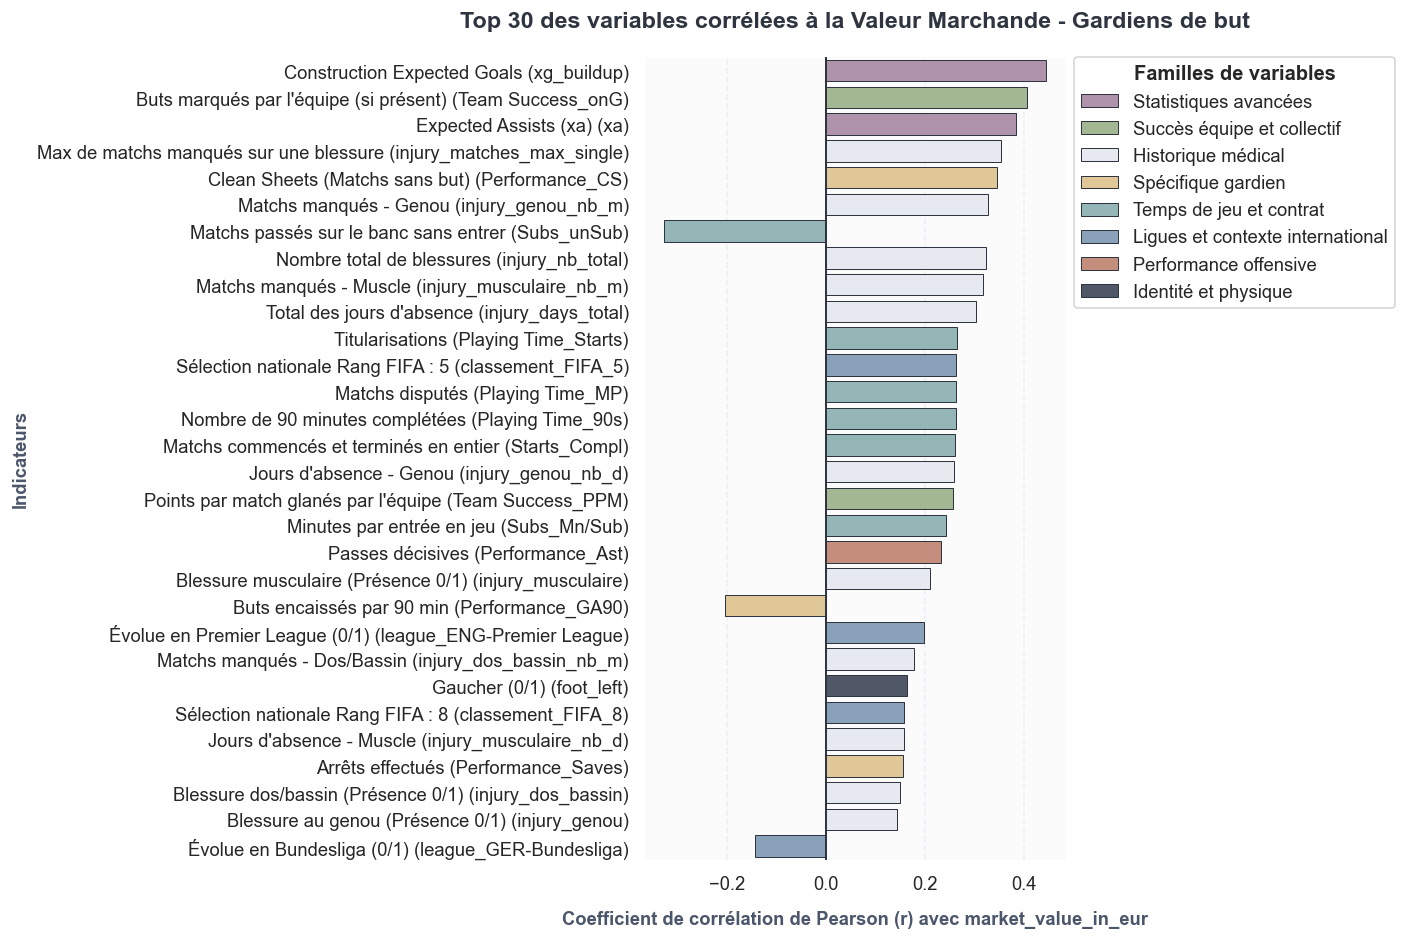

,Variable,Description,Famille,Corr_Cible_Brute
0,xg_buildup,Construction Expected Goals (xg_buildup),Statistiques avancées,0.445
1,Team Success_onG,Buts marqués par l'équipe (si présent) (Team S...,Succès équipe et collectif,0.406
2,xa,Expected Assists (xa) (xa),Statistiques avancées,0.383
3,injury_matches_max_single,Max de matchs manqués sur une blessure (injury...,Historique médical,0.353
4,Performance_CS,Clean Sheets (Matchs sans but) (Performance_CS),Spécifique gardien,0.346
5,injury_genou_nb_m,Matchs manqués - Genou (injury_genou_nb_m),Historique médical,0.327
6,Subs_unSub,Matchs passés sur le banc sans entrer (Subs_un...,Temps de jeu et contrat,-0.327
7,injury_nb_total,Nombre total de blessures (injury_nb_total),Historique médical,0.323
8,injury_musculaire_nb_m,Matchs manqués - Muscle (injury_musculaire_nb_m),Historique médical,0.316
9,injury_days_total,Total des jours d'absence (injury_days_total),Historique médical,0.303


In [22]:
# On applique la fonction
tableau_importance = analyser_variables_les_plus_explicatives(df_base,
                                                              target_col=TARGET,
                                                              top_n=30,
                                                              afficher_nom_technique=True,
                                                              uniquement_gardiens=True)

# On affiche le tableau propre sous le graphique
display(tableau_importance)

In [23]:
# Filtrez sur les gardiens uniquement avant de calculer la corrélation
df_gardiens = df_base[df_base["pos_GK"] == 1]

# Calculez la corrélation pearson
print(df_gardiens[["Performance_GA", "market_value_in_eur"]].corr())

                     Performance_GA  market_value_in_eur
Performance_GA             1.000000             0.112063
market_value_in_eur        0.112063             1.000000


In [24]:
# Corrélation brute
print(df_gardiens[["Performance_GA", "market_value_in_eur"]].corr())

# Corrélation entre les buts encaissés et la VM, mais à temps de jeu strictement égal
p_corr = pg.partial_corr(
    data=df_gardiens,
    x="Performance_GA",
    y="market_value_in_eur",
    covar="Playing Time_90s",
)

print(p_corr)

                     Performance_GA  market_value_in_eur
Performance_GA             1.000000             0.112063
market_value_in_eur        0.112063             1.000000
           n         r            CI95     p_val
pearson  188 -0.312465  [-0.44, -0.18]  0.000013


La corrélation à temps de jeu égal est bien négative : $-0.479881$, une valeur plus élevée que la corrélation de la colonne Performance_GA90 ($-0,20$). 

C'est parce que la variable Performance_GA90 (buts/90min) souffre d'un autre biais : le biais des petits échantillons.
Exemple : Un gardien remplaçant très faible entre en jeu, joue 10 minutes et prend 2 buts. Son ratio par 90 minutes explose (il monte à $18,0$ buts par match !). 

Ce genre de valeur extrême (outlier) vient "bruiter" et affaiblir votre corrélation Pearson classique sur la colonne des ratios.
La corrélation partielle, elle, étudie les volumes bruts sous contrôle mathématique. Elle contourne ce bruit des ratios extrêmes sur des petits temps de jeu, ce qui donne la vraie mesure de l'impact négatif des buts encaissés sur la valeur marchande d'un gardien.